In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install opencv-python scikit-learn seaborn tqdm

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from google.colab import drive, files
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import shutil
from datetime import datetime

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/DCSASS Dataset"
CACHE_PATH = "/content/dataset_cache.npz"

In [ ]:
IMG_SIZE = 64
MAX_FRAMES = 4
BATCH_SIZE = 16
EPOCHS = 25

In [ ]:
def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)
    frames = []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < MAX_FRAMES:
        cap.release()
        return None

    indices = np.linspace(0, total-1, MAX_FRAMES).astype(int)

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame / 255.0
            frames.append(frame)

    cap.release()

    if len(frames) != MAX_FRAMES:
        return None

    return np.array(frames)

In [ ]:
if not os.path.exists(CACHE_PATH):

    print("Processing dataset...")
    X, y = [], []

    class_names = sorted(os.listdir(DATASET_PATH))

    for label, class_name in enumerate(class_names):

        folder = os.path.join(DATASET_PATH, class_name)

        for video in tqdm(os.listdir(folder)):
            path = os.path.join(folder, video)

            frames = extract_frames(path)

            if frames is not None:
                X.append(frames)
                y.append(label)

    X = np.array(X)
    y = np.array(y)

    np.savez(CACHE_PATH, X=X, y=y)

else:
    print("Loading cached dataset...")
    data = np.load(CACHE_PATH)
    X = data["X"]
    y = data["y"]

class_names = sorted(os.listdir(DATASET_PATH))
print("Dataset Shape:", X.shape)

Loading cached dataset...
Dataset Shape: (8127, 4, 64, 64, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = tf.keras.utils.to_categorical(y_train, len(class_names))
y_test = tf.keras.utils.to_categorical(y_test, len(class_names))

In [ ]:
model = Sequential([

    TimeDistributed(Conv2D(16, (3,3), activation='relu'),
                    input_shape=(MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)),
    TimeDistributed(MaxPooling2D(2,2)),

    TimeDistributed(Conv2D(32, (3,3), activation='relu')),
    TimeDistributed(MaxPooling2D(2,2)),

    TimeDistributed(Flatten()),

    LSTM(64),

    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 4, 62, 62, 16)  │           448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 4, 31, 31, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 4, 29, 29, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 4, 14, 14, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 4, 6272)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     1,622,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,300 (6.23 MB)

 Trainable params: 1,632,300 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_accuracy',
#     patience=5,
#     restore_best_weights=True
# )

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    # callbacks=[early_stop]
)

Epoch 1/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 189s 453ms/step - accuracy: 0.6482 - loss: 1.1004 - val_accuracy: 0.9779 - val_loss: 0.1054
Epoch 2/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 200s 450ms/step - accuracy: 0.9786 - loss: 0.0895 - val_accuracy: 0.9895 - val_loss: 0.0311
Epoch 3/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 184s 453ms/step - accuracy: 0.9918 - loss: 0.0351 - val_accuracy: 0.9951 - val_loss: 0.0236
Epoch 4/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 180s 443ms/step - accuracy: 0.9891 - loss: 0.0378 - val_accuracy: 0.9945 - val_loss: 0.0169
Epoch 5/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 199s 435ms/step - accuracy: 0.9908 - loss: 0.0252 - val_accuracy: 0.9846 - val_loss: 0.0430
Epoch 6/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 203s 437ms/step - accuracy: 0.9929 - loss: 0.0200 - val_accuracy: 0.9938 - val_loss: 0.0148
Epoch 7/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 178s 438ms/step - accuracy: 0.9957 - loss: 0.0119 - val_accuracy: 0.9772 - val_loss: 0.0615
Epoch 8/25
407/407 ━━━━━━━━━━━━━━━━━━━━ 177s 434ms/step - accuracy: 0.9812 -

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 275ms/step
Accuracy: 0.992619926199262

Classification Report:

               precision    recall  f1-score   support

        Abuse       1.00      1.00      1.00       171
       Arrest       0.96      0.99      0.98       167
      Assault       1.00      1.00      1.00       130
     Burglary       0.99      1.00      1.00       155
    Explosion       1.00      1.00      1.00       153
     Fighting       1.00      1.00      1.00        57
RoadAccidents       1.00      0.98      0.99       161
      Robbery       1.00      1.00      1.00       145
     Shooting       0.98      0.94      0.96       120
  Shoplifting       0.99      1.00      1.00       114
     Stealing       1.00      1.00      1.00       112
    Vandalism       0.99      0.99      0.99       141

     accuracy                           0.99      1626
    macro avg       0.99      0.99      0.99      1626
 weighted avg       0.99      0.99      0.99      1626



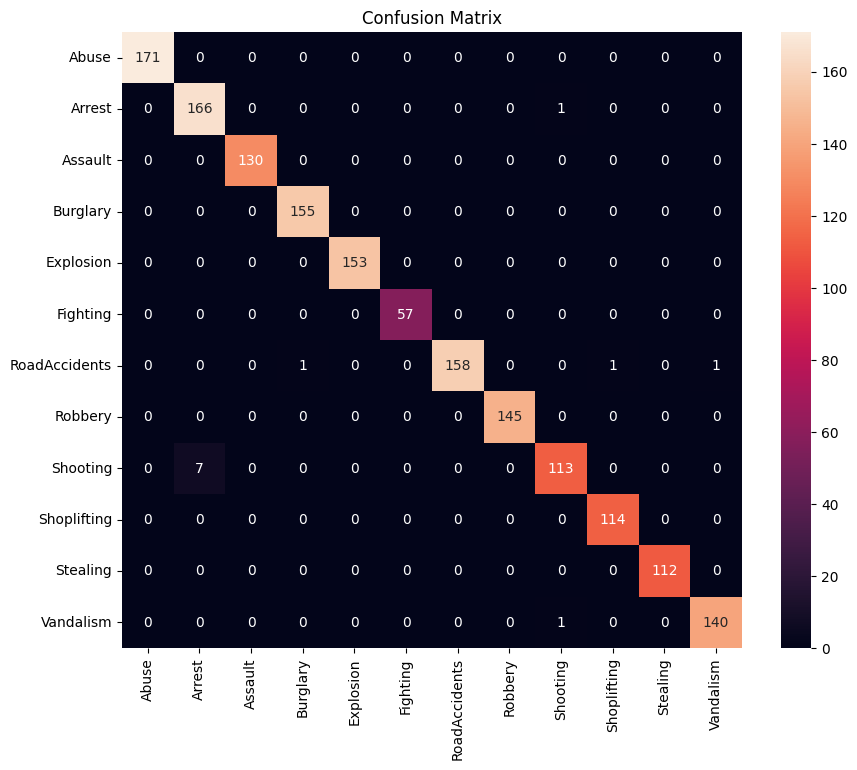

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

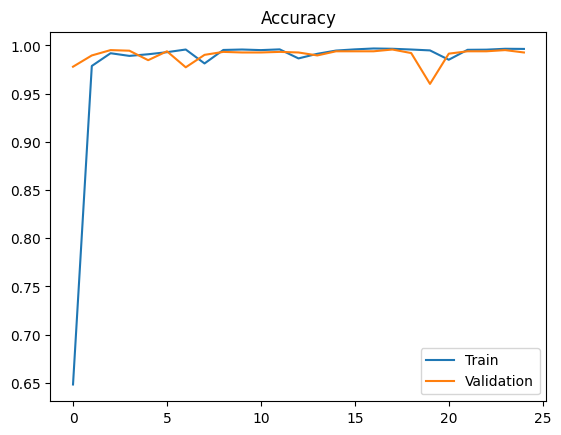

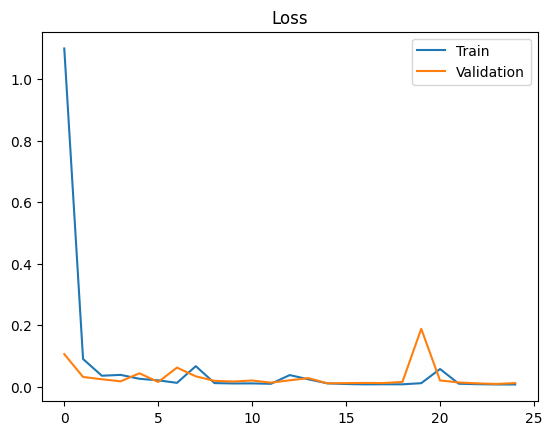

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

In [ ]:
def send_email_alert(predicted_class):

    try:
        sender_email = "extra01dummy@gmail.com"
        receiver_email = "patelkavya8306@gmail.com"
        app_password = "vdcq xhqt flof qnzx"

        msg = MIMEMultipart()
        msg["From"] = sender_email
        msg["To"] = receiver_email
        msg["Subject"] = "🚨 CCTV ALERT: Suspicious Activity Detected"

        body = f"""
          ALERT!

          Suspicious activity detected:
          {predicted_class}

          Please take immediate action.
          """

        msg.attach(MIMEText(body, "plain"))

        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_string())
        server.quit()

        print("Email sent successfully")

    except Exception as e:
        print("Email error:", e)

In [ ]:
def save_video(video_path):

    if not os.path.exists("alerts"):
        os.makedirs("alerts")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = f"alerts/alert_{timestamp}.mp4"

    shutil.copy(video_path, save_path)

    print("Video saved at:", save_path)

In [ ]:
uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded:", uploaded_filename)

Saving Fighting002_x264_1.mp4 to Fighting002_x264_1.mp4
Uploaded: Fighting002_x264_1.mp4


In [ ]:
def predict_video(video_path):

    frames = extract_frames(video_path)

    if frames is None:
        print("Frame extraction failed")
        return

    frames = np.expand_dims(frames, axis=0)

    prediction = model.predict(frames)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print("Predicted Class:", predicted_class)
    print("Confidence:", confidence)

    # ALWAYS send email
    send_email_alert(predicted_class)

    # ALWAYS save video
    save_video(video_path)

In [ ]:
predict_video(uploaded_filename)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Class: Fighting
Confidence: 0.9999999
Email sent successfully
Video saved at: alerts/alert_20260324_104657.mp4


In [ ]:
!pip install scikit-image opencv-python matplotlib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fighting002_x264_1.mp4 to Fighting002_x264_1 (1).mp4


In [ ]:
video_path = list(uploaded.keys())[0]
print(video_path)

Fighting002_x264_1 (1).mp4


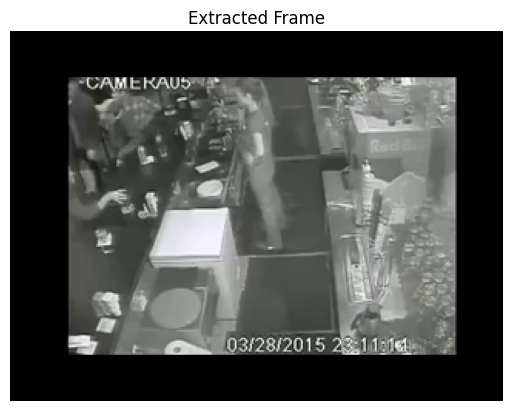

In [ ]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video")

ret, frame = cap.read()

if not ret:
    print("Error: Cannot read frame from video")
else:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.title("Extracted Frame")
    plt.axis("off")
    plt.show()

cap.release()

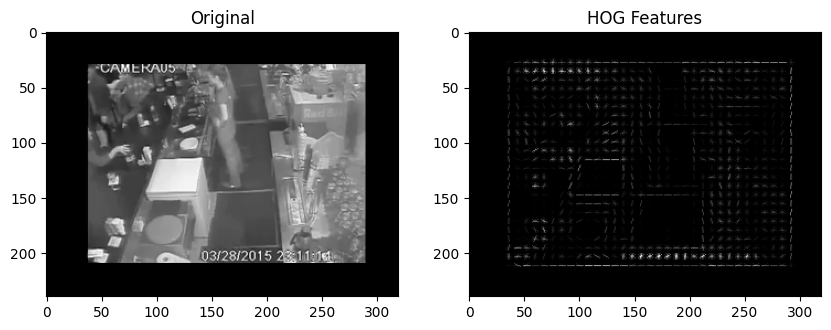

HOG Feature Vector Length: 40716


In [ ]:
from skimage.feature import hog

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Features")

plt.show()

print("HOG Feature Vector Length:", len(features))

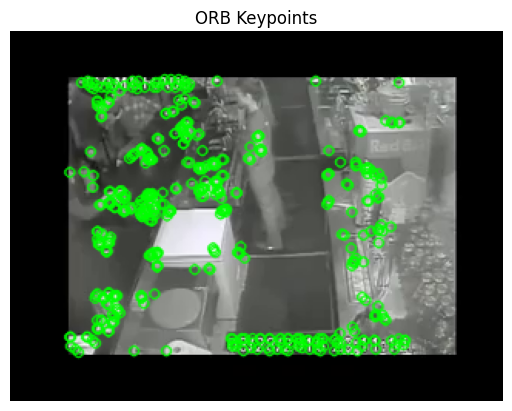

Number of ORB keypoints: 448


In [ ]:
orb = cv2.ORB_create()

keypoints, descriptors = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(
    frame,
    keypoints,
    None,
    color=(0,255,0),
    flags=0
)

plt.imshow(cv2.cvtColor(orb_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis("off")
plt.show()

print("Number of ORB keypoints:", len(keypoints))

In [ ]:
model.save('/content/drive/MyDrive/project/aimodel.h5')